# Cross-method benchmarking: capabilities, semantics, and honest cost

A benchmark should not flatten IID samples, weighted particles, exact Markov chains,
and approximate deterministic flows into one fake leaderboard. Sampler Lab first checks
whether a method can run on a target, then records output semantics, training cost,
evaluation cost, distributional error, and mode-mixing diagnostics separately.

This tutorial builds a small replicated benchmark, visualizes exclusions, and constructs
a Pareto frontier in discrepancy versus total training-plus-evaluation time.

In [1]:
import importlib.metadata
import os
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from sampler_lab.benchmarks import (
    BenchmarkConfig,
    adapter_by_name,
    check_compatibility,
    correlated_gaussian_case,
    default_continuous_adapters,
    default_continuous_cases,
    imq_mmd,
    markdown_summary,
    normalized_log_weights,
    pareto_frontier,
    run_benchmark_suite,
    separated_gaussian_mixture_case,
    weighted_imq_mmd,
    write_report_bundle,
)

QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
SEED = 2022
FIGURE_COUNT = 0


def finish_figure(fig):
    global FIGURE_COUNT
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    FIGURE_COUNT += 1


print("sampler-lab", importlib.metadata.version("sampler-lab"))
print("execution mode:", "quick" if QUICK_MODE else "publication")
print("master seed:", SEED)

sampler-lab 0.12.0
execution mode: publication
master seed: 2022


## 1. Capability checks precede scores

Targets declare whether they have gradients, Hessians, normalized densities, exact
reference sampling, and multimodality. Samplers declare what they require and what they
produce. Unsupported pairs become explicit exclusions, not failures and certainly not
fabricated numbers.

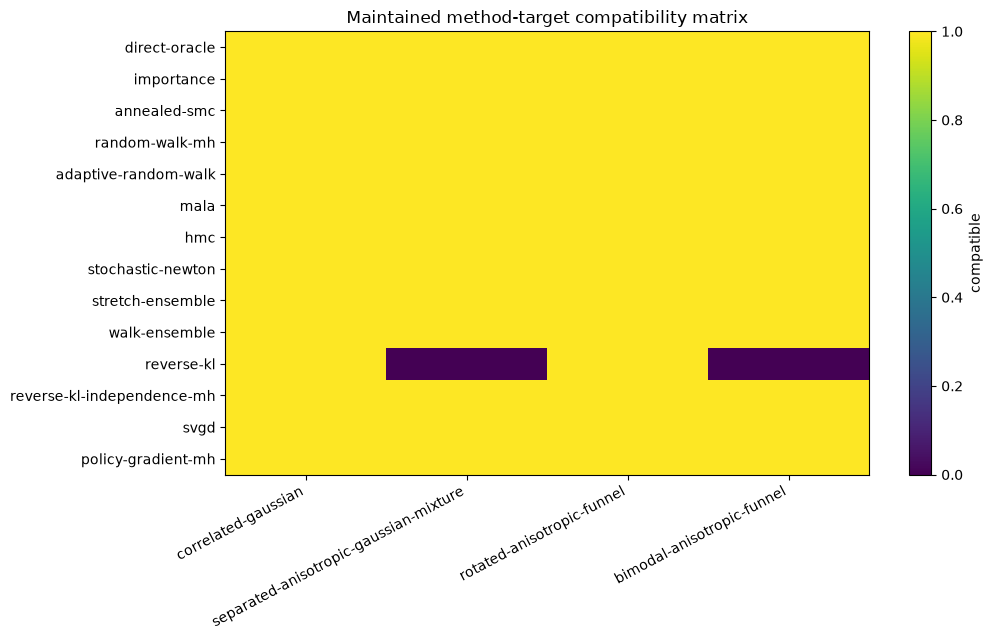

explicit exclusions:
  reverse-kl x separated-anisotropic-gaussian-mixture -> sampler adapter does not support multimodal targets
  reverse-kl x bimodal-anisotropic-funnel -> sampler adapter does not support multimodal targets


In [2]:
maintained_cases = default_continuous_cases()
maintained_adapters = default_continuous_adapters()
compatibility = np.zeros(
    (len(maintained_adapters), len(maintained_cases)),
    dtype=float,
)
exclusion_reasons = []
for method_index, adapter in enumerate(maintained_adapters):
    for target_index, case in enumerate(maintained_cases):
        result = check_compatibility(adapter.capabilities, case.capabilities)
        compatibility[method_index, target_index] = float(result.compatible)
        if not result.compatible:
            exclusion_reasons.append((adapter.name, case.name, result.reasons))

fig, axis = plt.subplots(figsize=(10.5, 6.5))
image = axis.imshow(compatibility, aspect="auto", vmin=0.0, vmax=1.0)
axis.set_xticks(range(len(maintained_cases)))
axis.set_xticklabels([case.name for case in maintained_cases], rotation=28, ha="right")
axis.set_yticks(range(len(maintained_adapters)))
axis.set_yticklabels([adapter.name for adapter in maintained_adapters])
axis.set_title("Maintained method-target compatibility matrix")
fig.colorbar(image, ax=axis, label="compatible")
finish_figure(fig)

print("explicit exclusions:")
for method, target, reasons in exclusion_reasons[:12]:
    print(" ", method, "x", target, "->", "; ".join(reasons))
assert np.any(compatibility == 0.0)
assert np.any(compatibility == 1.0)

## 2. Weighted and unweighted empirical measures need compatible metrics

IMQ maximum mean discrepancy compares empirical distributions to trusted reference
samples. Weighted output must use normalized log weights inside the kernel averages;
pretending weighted particles are uniform can reverse the conclusion.

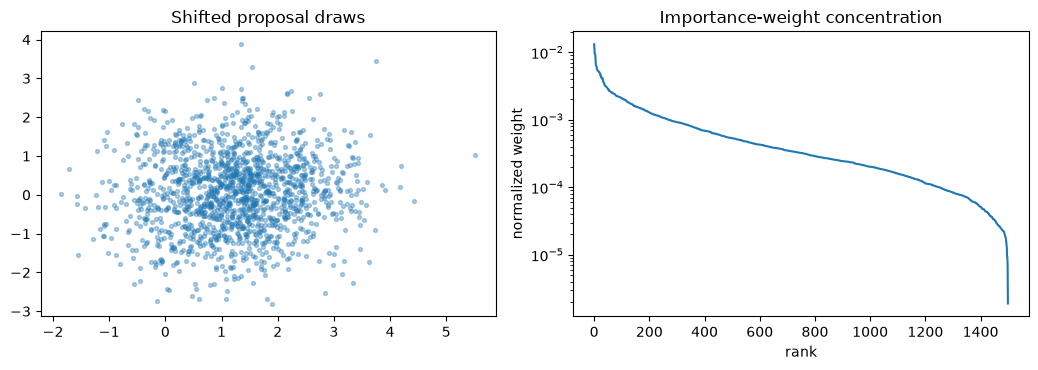

unweighted proposal MMD: 0.3647620740067215
weighted empirical-measure MMD: 0.1095166070264209


In [3]:
rng = np.random.default_rng(SEED)
reference = rng.normal(size=(500 if QUICK_MODE else 1_500, 2))
proposal = rng.normal(loc=np.array([1.2, 0.0]), size=reference.shape)
log_weights = -0.5 * np.sum(proposal**2, axis=1) + 0.5 * np.sum(
    (proposal - np.array([1.2, 0.0])) ** 2,
    axis=1,
)
weights = normalized_log_weights(log_weights)
unweighted_mmd = imq_mmd(proposal, reference)
weighted_mmd = weighted_imq_mmd(proposal, log_weights, reference)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].scatter(proposal[:, 0], proposal[:, 1], s=8, alpha=0.35)
axes[0].set_title("Shifted proposal draws")
order = np.argsort(weights)[::-1]
axes[1].plot(weights[order])
axes[1].set_yscale("log")
axes[1].set_xlabel("rank")
axes[1].set_ylabel("normalized weight")
axes[1].set_title("Importance-weight concentration")
finish_figure(fig)

print("unweighted proposal MMD:", unweighted_mmd)
print("weighted empirical-measure MMD:", weighted_mmd)
assert np.isclose(np.sum(weights), 1.0)
assert weighted_mmd < unweighted_mmd

## 3. A replicated suite with mixed output semantics

The suite below compares exact IID draws, weighted importance samples, exact local
chains, adaptive MH, gradient-based chains, and an approximate reverse-KL fit on a
correlated Gaussian and a separated mixture. Replicates use deterministic independent
seeds and shared reference samples within each target/replicate pair.

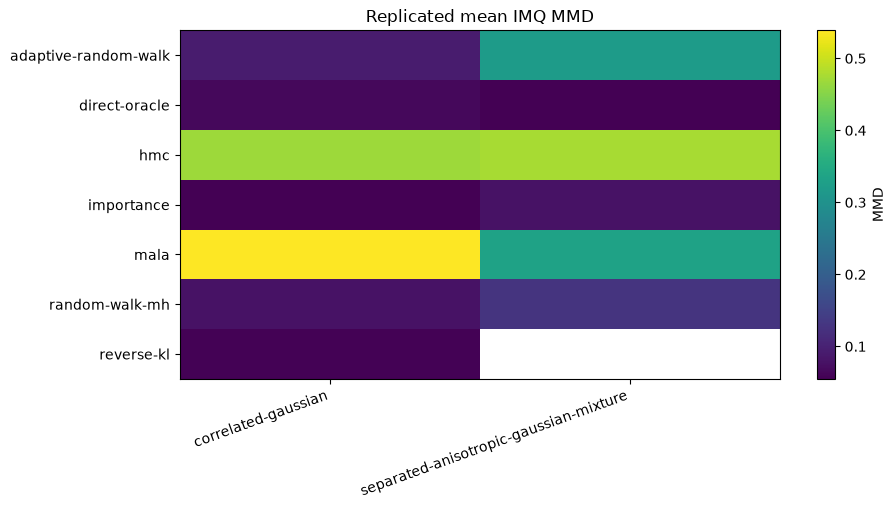

results: 26
exclusions: 1
failures: 0
excluded: reverse-kl x separated-anisotropic-gaussian-mixture ('sampler adapter does not support multimodal targets',)


In [4]:
cases = (
    correlated_gaussian_case(dimension=2, condition_number=25.0, seed=11),
    separated_gaussian_mixture_case(
        dimension=2,
        separation=6.0,
        condition_number=4.0,
        seed=19,
    ),
)
method_names = (
    "direct-oracle",
    "importance",
    "random-walk-mh",
    "adaptive-random-walk",
    "mala",
    "hmc",
    "reverse-kl",
)
adapters = tuple(adapter_by_name(name) for name in method_names)
config = BenchmarkConfig(
    n_samples=150 if QUICK_MODE else 450,
    warmup_steps=45 if QUICK_MODE else 140,
    reference_samples=180 if QUICK_MODE else 450,
    n_walkers=16,
    variational_steps=8 if QUICK_MODE else 30,
    policy_updates=5 if QUICK_MODE else 15,
    policy_rollout_length=4,
    svgd_particles=24,
    svgd_steps=4,
    annealing_particles=48,
    annealing_steps=5,
    seed=SEED,
)
suite = run_benchmark_suite(
    config=config,
    n_replicates=2,
    seed=SEED,
    cases=cases,
    adapters=adapters,
)
aggregates = suite.aggregates

target_names = [case.name for case in cases]
aggregate_methods = sorted({row.method for row in aggregates})
mmd_matrix = np.full((len(aggregate_methods), len(target_names)), np.nan)
for row in aggregates:
    if row.imq_mmd_mean is not None:
        mmd_matrix[
            aggregate_methods.index(row.method),
            target_names.index(row.target),
        ] = row.imq_mmd_mean

fig, axis = plt.subplots(figsize=(9.5, 5.2))
image = axis.imshow(mmd_matrix, aspect="auto")
axis.set_xticks(range(len(target_names)))
axis.set_xticklabels(target_names, rotation=20, ha="right")
axis.set_yticks(range(len(aggregate_methods)))
axis.set_yticklabels(aggregate_methods)
axis.set_title("Replicated mean IMQ MMD")
fig.colorbar(image, ax=axis, label="MMD")
finish_figure(fig)

print("results:", len(suite.results))
print("exclusions:", len(suite.exclusions))
print("failures:", len(suite.failures))
for exclusion in suite.exclusions:
    print("excluded:", exclusion.method, "x", exclusion.target, exclusion.reasons)
assert not suite.failures
assert suite.results
assert any(result.output_semantics == "weighted-samples" for result in suite.results)
assert any(not result.exact_after_freeze for result in suite.results)

## 4. Pareto frontiers include training cost

A learned method cannot hide optimization time, and an exact method cannot hide poor
distributional accuracy behind a high acceptance rate. The frontier below uses IMQ MMD
and total training plus evaluation wall time. It is target-specific and does not claim
a universal winner.

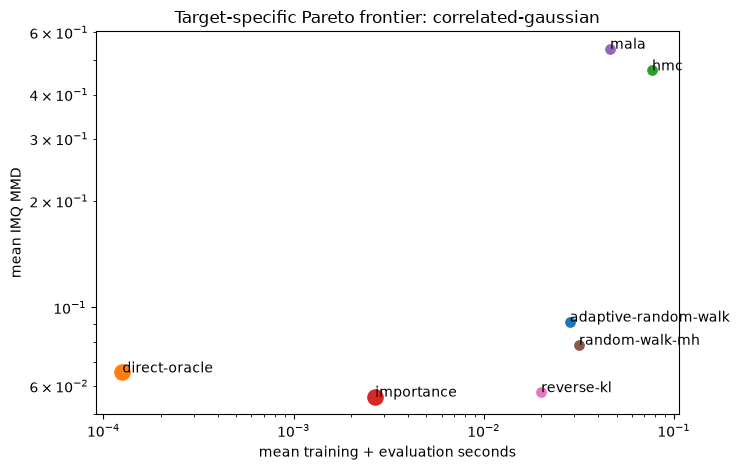

Pareto methods: ['direct-oracle', 'importance']


In [5]:
frontier_target = cases[0].name
candidates = [
    row for row in aggregates if row.target == frontier_target and row.imq_mmd_mean is not None
]
frontier = pareto_frontier(aggregates, target=frontier_target)
frontier_keys = {(row.method, row.target) for row in frontier}

fig, axis = plt.subplots(figsize=(7.5, 4.8))
for row in candidates:
    marker_size = 120 if (row.method, row.target) in frontier_keys else 45
    axis.scatter(
        row.total_seconds_mean,
        row.imq_mmd_mean + 1e-12,
        s=marker_size,
    )
    axis.annotate(row.method, (row.total_seconds_mean, row.imq_mmd_mean + 1e-12))
axis.set_xscale("log")
axis.set_yscale("log")
axis.set_xlabel("mean training + evaluation seconds")
axis.set_ylabel("mean IMQ MMD")
axis.set_title(f"Target-specific Pareto frontier: {frontier_target}")
finish_figure(fig)

print("Pareto methods:", [row.method for row in frontier])
assert frontier

## 5. Reports preserve configuration, exclusions, and failures

Machine-readable JSON/CSV and a Markdown summary are generated from the same suite
object. Partial progress is retained if an adapter fails, and capability exclusions are
recorded alongside successful results.

In [6]:
with tempfile.TemporaryDirectory() as directory:
    output_dir = Path(directory)
    paths = write_report_bundle(suite, output_dir)
    print(markdown_summary(suite).splitlines()[0:18])
    print("report files:", sorted(path.name for path in paths))
    assert all(path.exists() for path in paths)
    assert any(path.suffix == ".json" for path in paths)
    assert any(path.suffix == ".md" for path in paths)

['# Sampler Lab Continuous Benchmark', '', '- Package version: `0.12.0`', '- Replicates: 2', '- Base seed: 2022', '- Successful runs: 26', '- Excluded pairings: 1', '- Failed runs: 0', '', '## Aggregate metrics', '', '| Target | Method | Semantics | Exact after freeze | Mean error | Covariance error | IMQ-MMD | Mode L1 | Train seconds | Eval seconds | Total seconds |', '|---|---|---|---:|---:|---:|---:|---:|---:|---:|---:|', '| correlated-gaussian | adaptive-random-walk | markov-chain | True | 0.1159 | 0.08413 | 0.09114 | -- | 0.005024 | 0.02332 | 0.02834 |', '| separated-anisotropic-gaussian-mixture | adaptive-random-walk | markov-chain | True | 0.7128 | 0.8124 | 0.3199 | 0.8578 | 0.008212 | 0.03936 | 0.04757 |', '| correlated-gaussian | direct-oracle | iid-samples | True | 0.01602 | 0.06434 | 0.06547 | -- | 0 | 0.0001259 | 0.0001259 |', '| separated-anisotropic-gaussian-mixture | direct-oracle | iid-samples | True | 0.03946 | 0.03953 | 0.05484 | 0.03556 | 0 | 7.941e-05 | 7.941e-05 |'

## Takeaways

- Compatibility is part of the result, not an inconvenient precondition.
- Weighted particles, approximate particles, IID draws, and Markov chains require
  different diagnostics and explicit semantic labels.
- Replication uncertainty matters; a single deterministic run is a demo, not a ranking.
- Training and evaluation costs belong on the same cost frontier.
- Pareto frontiers are target-specific. A universal scalar winner score would mostly
  measure the benchmark author's taste.

In [7]:
assert FIGURE_COUNT >= 4
print("figures rendered:", FIGURE_COUNT)

figures rendered: 4
